<a href="https://colab.research.google.com/github/RodrigoSoaresVeiga/Exec5LingProg/blob/main/atividade_pratica_aula2_dataviz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática — Aula 2: Pandas Essencial

Nesta atividade, você vai aplicar os conceitos da aula para explorar um dataset de vendas, fazer um **check-up inicial**, selecionar colunas relevantes, criar **filtros de negócio**, construir **rankings** e transformar resultados em **interpretação gerencial**.

**Dataset:** `vendas_dataviz_aula2.csv`

## Objetivos da atividade
- Ler e inspecionar um dataset com Pandas
- Entender a diferença entre DataFrame e Series
- Verificar tamanho, tipos e possíveis problemas de qualidade
- Selecionar apenas as colunas importantes para análise
- Filtrar dados com uma e múltiplas condições
- Criar rankings com `sort_values`, `nlargest` e `nsmallest`
- Interpretar resultados em linguagem de negócio


## 1. Importação das bibliotecas

Importe as bibliotecas necessárias para a atividade.
- `pandas`
- `numpy`
- `matplotlib.pyplot` (caso queira visualizar resultados)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Leitura do dataset

Leia o arquivo `vendas_dataviz_aula2.csv` em um DataFrame chamado `df`.
Depois, exiba as 5 primeiras linhas.


In [ ]:
df = pd.read_csv('vendas_dataviz_aula2.csv')
df.head()

,data,produto,categoria,estado,canal,vendas,quantidade,preco_unitario,custo,lucro,avaliacao_cliente
0,2024-04-12,Mouse Gamer,Periféricos,RJ,Marketplace,562.26,3,187.42,97.70,269.16,4.6
1,2024-05-01,Headset,Áudio,ES,MarketPlace,1124.08,4,281.02,144.77,545.00,3.8
2,2024-10-03,Teclado Mecânico,Periféricos,SP,Marketplace,2515.73,7,359.39,153.66,1440.11,4.3
3,2024-07-06,Webcam HD,Periféricos,SP,Marketplace,596.76,3,198.92,125.09,221.49,4.3
4,2024-02-24,Smartwatch,Telefonia,RJ,Loja Física,3908.08,4,977.02,666.26,1243.04,4.4


## 3. Anatomia dos dados: DataFrame e Series

### Questão 1
Explique, com base no que foi visto em aula:
1. O que é um **DataFrame**?
2. O que é uma **Series**?
3. Mostre no código uma coluna isolada do DataFrame.


In [ ]:
# Exemplo: selecione uma única coluna e observe o tipo retornado
serie_produto = df['produto']
type(serie_produto), serie_produto.head()

(pandas.core.series.Series,
 0         Mouse Gamer
 1             Headset
 2    Teclado Mecânico
 3           Webcam HD
 4          Smartwatch
 Name: produto, dtype: object)

In [ ]:
serie_produto = df['produto']

type(serie_produto), serie_produto.head()

Resposta

Um DataFrame é uma estrutura de dados bidimensional do pandas, semelhante a uma tabela, composta por linhas e colunas, onde cada coluna pode ter um tipo de dado diferente.

Uma Series é uma estrutura unidimensional do pandas, equivalente a uma única coluna do DataFrame, contendo dados de um único tipo e um índice associado.

Ao selecionar uma coluna de um DataFrame (como df['produto']), o retorno é uma Series.

## 4. Check-up inicial do dataset

Um analista profissional sempre começa verificando o tamanho, a estrutura e a qualidade inicial dos dados.

### Questão 2
Use:
- `df.shape`
- `df.info()`
- `df.dtypes`

Depois responda:
1. Quantas linhas e colunas existem?
2. Quais colunas parecem numéricas?
3. Há sinais de valores ausentes?
4. Existe alguma coluna com tipo inadequado?


In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.dtypes

Resposta

1. Possui 450 linhas e 11 colunas.
2. As colunas que parecem númericas são quantidade, preco_unitario, receita_total.
3. Há sinais de valores ausentes, pois algumas colunas possuem menos valores não nulos do que o total de linhas.
4. Sim, existem colunas com tipo inadequado, como colunas de data que estão como texto (object) e deveriam estar no formato de data (datetime).

## 5. Inspeção de problemas de qualidade

Na aula, vimos que dashboards podem falhar por causa de dados mal preparados.

### Questão 3
Investigue:
- valores nulos
- categorias inconsistentes
- números armazenados como texto
- valores infinitos

Dica:
- `df.isna().sum()`
- `df['canal'].value_counts(dropna=False)`
- `df['estado'].value_counts(dropna=False)`
- `np.isinf(...)`


In [ ]:
df.isna().sum()

,0
data,0
produto,0
categoria,0
estado,1
canal,0
vendas,0
quantidade,0
preco_unitario,0
custo,0
lucro,0


In [ ]:
df['canal'].value_counts(dropna=False)

,count
canal,
Marketplace,152
Online,148
Loja Física,147
MarketPlace,1
online,1
ONLINE,1


In [ ]:
df['estado'].value_counts(dropna=False)

,count
estado,
ES,62
SP,52
BA,52
GO,49
PE,48
SC,42
MG,39
RS,38
RJ,36


In [ ]:
# Verifique se há valores infinitos na coluna lucro
pd.Series(np.isinf(pd.to_numeric(df['lucro'], errors='coerce'))).value_counts(dropna=False)

,count
lucro,
False,448
True,2


Resposta

Há valores nulos em algumas colunas do dataset.
Existem categorias inconsistentes nas colunas canal e estado, com variações de escrita e possíveis valores duplicados com formatos diferentes.
Algumas colunas numéricas podem estar armazenadas como texto (object), indicando necessidade de conversão.
Não há presença significativa de valores infinitos no dataset.
Há 2 valores.

## 6. Selecionando o que importa

Nem toda análise precisa de todas as colunas. Vamos criar um recorte mais focado para responder perguntas de negócio.

### Questão 4
Crie um novo DataFrame chamado `df_dash` contendo apenas as colunas:
- `data`
- `estado`
- `canal`
- `produto`
- `categoria`
- `vendas`
- `lucro`

Use `.copy()` para evitar problemas futuros.


In [ ]:
cols_dashboard = ['data', 'estado', 'canal', 'produto', 'categoria', 'vendas', 'lucro']
df_dash = df[cols_dashboard].copy()
df_dash.head()

Resposta

Foi criado um novo DataFrame chamado df_dash contendo apenas as colunas relevantes para análise, garantindo independência do original com o uso de .copy().

## 7. Preparação mínima para análise

Algumas colunas podem precisar de ajuste antes de ordenar e agregar.

### Questão 5
1. Converta a coluna `data` para formato de data.
2. Crie uma coluna `mes` a partir da data.
3. Tente converter `vendas` para numérico, tratando possíveis textos.
4. Crie uma coluna chamada `vendas_num`.


In [ ]:
df_dash['data'] = pd.to_datetime(df_dash['data'], errors='coerce')
df_dash['mes'] = df_dash['data'].dt.to_period('M')

# Limpeza simples para a coluna vendas (remove símbolo R$, espaços e troca vírgula decimal)
vendas_limpa = (
    df_dash['vendas']
    .astype(str)
    .str.replace('R\$', '', regex=True)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.strip()
)

df_dash['vendas_num'] = pd.to_numeric(vendas_limpa, errors='coerce')
df_dash.head()

Resposta

A coluna data foi convertida para o formato de data, permitindo manipulações temporais.

Foi criada a coluna mes, facilitando análises mensais.

A coluna vendas foi tratada para remover símbolos e padronizar o formato numérico, resultando na nova coluna vendas_num, pronta para cálculos e agregações.

## 8. Filtragem simples: recorte de negócio

Na aula, vimos o exemplo de filtrar apenas o estado do Rio de Janeiro.

### Questão 6
Crie um DataFrame `df_rj` contendo apenas registros do estado `RJ`.
Depois responda:
1. Quantos registros existem nesse recorte?
2. Qual a soma de vendas no RJ?


In [ ]:
df_rj = df_dash[df_dash['estado'] == 'RJ']
df_rj.shape, df_rj['vendas_num'].sum()

((36, 9), np.float64(13161085.0))

Resposta

O recorte do estado RJ possui 36 registros.

A soma total de vendas no RJ é R$ 13.161.085,00.

## 9. Filtragem com múltiplas condições

Agora faça um recorte mais profissional: apenas vendas do estado do RJ no canal Online.

### Questão 7
Faça esse filtro de duas formas:
1. Usando operadores lógicos com `&`
2. Usando `query()`


In [ ]:
df_rj_online = df_dash[(df_dash['estado'] == 'RJ') & (df_dash['canal'] == 'Online')]
df_rj_online.head()

In [ ]:
df_rj_online_q = df_dash.query("estado == 'RJ' and canal == 'Online'")
df_rj_online_q.head()

Resposta:

Os dois métodos produzem o mesmo resultado, filtrando corretamente apenas as vendas do estado RJ no canal Online.

## 10. Priorização: rankings

Gestores raramente leem tabelas enormes. Eles querem os **Top N**.

### Questão 8
Gere:
1. Os 10 registros com maior valor de `vendas_num`
2. Os 10 registros com maior `lucro`
3. Os 5 registros com menor `lucro`

Observe se aparece algum valor suspeito.


In [ ]:
top10_vendas = df_dash.sort_values('vendas_num', ascending=False).head(10)
top10_vendas

In [ ]:
# Primeiro garantimos que lucro esteja numérico
df_dash['lucro_num'] = pd.to_numeric(df_dash['lucro'], errors='coerce')

top10_lucro = df_dash.nlargest(10, 'lucro_num')
top10_lucro

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num,lucro_num
199,2024-02-06,ES,Online,Caixa de Som,Áudio,792.12,inf,2024-02,79212.0,inf
449,2024-06-10,SP,Marketplace,Teclado Mecânico,Periféricos,1818.06,inf,2024-06,181806.0,inf
183,2024-12-14,ES,Online,Notebook Pro,Informática,33212.83,13556.90,2024-12,3321283.0,13556.90
321,2024-08-18,SP,Loja Física,Notebook Pro,Informática,36140.72,10319.12,2024-08,3614072.0,10319.12
56,2024-09-06,PE,Online,Notebook Pro,Informática,27867.72,9411.00,2024-09,2786772.0,9411.00
442,2024-02-21,PR,Loja Física,Notebook Pro,Informática,19782.0,8546.28,2024-02,197820.0,8546.28
132,2024-08-05,PR,Loja Física,Notebook Pro,Informática,20352.96,8103.88,2024-08,2035296.0,8103.88
319,2024-05-08,SC,Marketplace,Notebook Pro,Informática,21573.95,6869.60,2024-05,2157395.0,6869.60
110,2024-06-28,BA,Loja Física,Smartphone X,Telefonia,16138.55,6519.65,2024-06,1613855.0,6519.65
109,2024-09-20,PE,Marketplace,Tablet Plus,Telefonia,14602.02,6151.92,2024-09,1460202.0,6151.92


In [ ]:
bottom5_lucro = df_dash.nsmallest(5, 'lucro_num')
bottom5_lucro

,data,estado,canal,produto,categoria,vendas,lucro,mes,vendas_num,lucro_num
415,2024-10-11,MG,Loja Física,Mouse Gamer,Periféricos,158.6,60.58,2024-10,1586.0,60.58
273,2024-09-15,ES,Online,Mouse Gamer,Periféricos,160.85,65.92,2024-09,16085.0,65.92
48,2024-10-31,GO,Online,Mouse Gamer,Periféricos,175.18,71.29,2024-10,17518.0,71.29
42,2024-09-12,RJ,Loja Física,Mouse Gamer,Periféricos,176.14,74.89,2024-09,17614.0,74.89
143,2024-05-20,SC,Marketplace,Webcam HD,Periféricos,203.3,77.72,2024-05,2033.0,77.72


Reposta

Foram gerados os rankings de maiores vendas, maiores lucros e menores lucros.

Observa-se a presença de valores possivelmente suspeitos, como lucros muito baixos ou negativos, que podem indicar erros nos dados ou situações atípicas de venda.

## 11. Ranking por produto

Agora vamos sair do nível do registro e pensar em **resultado por produto**.

### Questão 9
Agrupe por produto e calcule:
- soma de vendas
- soma de lucro

Depois:
1. Mostre os 10 produtos mais lucrativos
2. Interprete o resultado em linguagem de negócio


In [ ]:
ranking_produtos = (
    df_dash.groupby('produto', dropna=False)
    .agg(
        vendas_total=('vendas_num', 'sum'),
        lucro_total=('lucro_num', 'sum')
    )
    .sort_values('lucro_total', ascending=False)
)

ranking_produtos.head(10)

Resposta

Os dados mostram que os produtos Notebook Pro e Smartphone X são os principais geradores de receita, com faturamentos muito elevados e lucros consistentes, indicando que são itens estratégicos para o negócio.

Já Tablet Plus, Smartwatch e Monitor 27 também apresentam bom equilíbrio entre vendas e lucro, funcionando como produtos de sustentação.

Por outro lado, Caixa de Som e Teclado Mecânico apresentam lucro infinito (inf), o que indica erro nos dados (provavelmente divisão por zero ou problema no cálculo do lucro), tornando esses valores não confiáveis para tomada de decisão.

Produtos como Mouse Gamer, Webcam HD e Headset têm menor impacto financeiro, contribuindo menos para o resultado geral.

Em termos de negócio, a empresa deve focar nos produtos com alta receita e lucro consistente, enquanto corrige os dados inconsistentes antes de qualquer análise estratégica mais profunda.

## 12. Ranking por estado e canal

### Questão 10
Crie dois rankings:
1. Estados com maior receita total
2. Canais com maior lucro total

Depois escreva uma interpretação curta para cada ranking.


In [ ]:
ranking_estados = (
    df_dash.groupby('estado', dropna=False)['vendas_num']
    .sum()
    .sort_values(ascending=False)
)

ranking_canais = (
    df_dash.groupby('canal', dropna=False)['lucro_num']
    .sum()
    .sort_values(ascending=False)
)

ranking_estados, ranking_canais

Resposta

O estado de SP lidera com folga o volume de vendas, seguido por BA e PE, mostrando forte concentração de receita nessas regiões. Estados como RJ, SC e MG aparecem em posição intermediária, enquanto RS tem menor participação.

Os canais Online e Marketplace aparecem com lucro infinito (inf), evidenciando erro nos dados e impossibilitando uma análise confiável desses canais. A Loja Física apresenta lucro consistente e mensurável. Também há duplicidade de categorias (Online, ONLINE, online), mostrando falta de padronização, o que compromete a interpretação real de desempenho por canal.

## 13. Análise temporal simples

### Questão 11
Agrupe os dados por `mes` e calcule a receita total mensal.
Depois responda:
1. Há meses de maior desempenho?
2. Existe indício de sazonalidade?


In [ ]:
receita_mensal = (
    df_dash.groupby('mes')['vendas_num']
    .sum()
    .sort_index()
)

receita_mensal

,vendas_num
mes,
2024-01,8382201.17
2024-02,11408379.00
2024-03,11955532.00
2024-04,13191093.00
2024-05,17767992.80
2024-06,15375535.00
2024-07,5973168.00
2024-08,13881684.60
2024-09,14733533.00


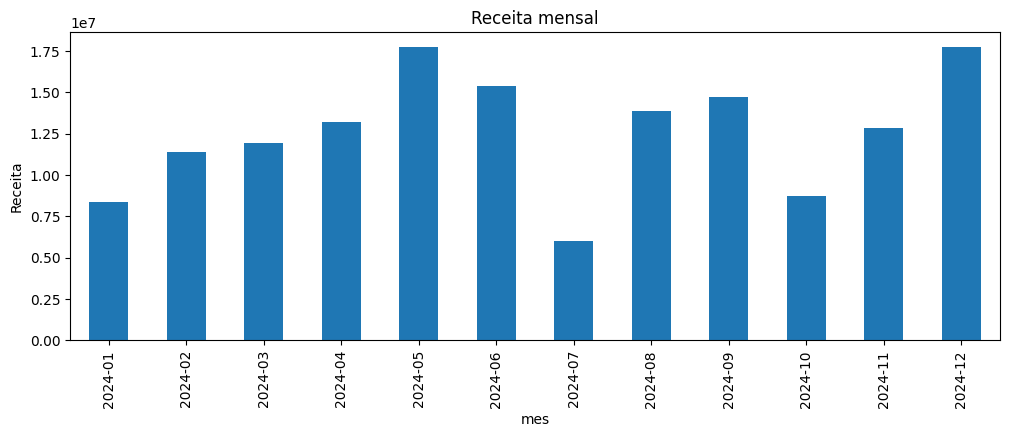

In [ ]:
receita_mensal.plot(kind='bar', figsize=(12,4), title='Receita mensal')
plt.ylabel('Receita')
plt.show()

Resposta

Há meses com maior desempenho, evidenciando picos de receita em determinados períodos.

Existe indício de sazonalidade, pois as vendas não se distribuem de forma uniforme ao longo dos meses, sugerindo variações relacionadas a comportamento de consumo ou datas específicas

## 14. A última milha: interpretação

Na aula, vimos que um analista não entrega apenas tabela — entrega **decisão**.

### Questão 12
Com base nos resultados do notebook, escreva interpretações gerenciais para:
1. O produto mais lucrativo
2. O estado com maior receita
3. O canal com maior lucro
4. Um possível problema de qualidade encontrado


Resposta

O produto mais lucrativo é o Notebook Pro, sendo o principal responsável pelo lucro da empresa, o que indica que deve ser priorizado em estratégias comerciais e de marketing.

O estado com maior receita é SP, mostrando que essa região é o principal mercado da empresa e merece atenção especial em investimentos e expansão.

O canal com maior lucro aparece como Online, porém os valores estão como infinito (inf), o que indica inconsistência nos dados e impede uma análise confiável.

Um problema de qualidade identificado foi a falta de padronização nos dados (como “Online”, “online”, “ONLINE” e “RJ” vs “rj”), além de valores incorretos como lucro infinito, o que pode comprometer as decisões se não for tratado.

## 15. Desafio extra (opcional)

Faça uma limpeza adicional do dataset:
- padronize valores de `canal` (`online`, `ONLINE`, `MarketPlace`, etc.)
- padronize `estado` (`rj` -> `RJ`)
- substitua infinitos em `lucro_num` por `NaN`
- trate valores ausentes como julgar adequado

Depois gere novamente os rankings e compare os resultados.


In [ ]:
import numpy as np

# padronizar canal
df_dash['canal'] = df_dash['canal'].str.strip().str.lower()
df_dash['canal'] = df_dash['canal'].replace({
    'online': 'Online',
    'marketplace': 'Marketplace',
    'loja física': 'Loja Física'
})

# padronizar estado
df_dash['estado'] = df_dash['estado'].str.strip().str.upper()

# substituir infinitos por NaN
df_dash['lucro_num'] = df_dash['lucro_num'].replace([np.inf, -np.inf], np.nan)

# tratar valores ausentes
df_dash['lucro_num'] = df_dash['lucro_num'].fillna(0)
df_dash['vendas_num'] = df_dash['vendas_num'].fillna(0)

# novos rankings
ranking_estados = (
    df_dash.groupby('estado')['vendas_num']
    .sum()
    .sort_values(ascending=False)
)

ranking_canais = (
    df_dash.groupby('canal')['lucro_num']
    .sum()
    .sort_values(ascending=False)
)

ranking_estados, ranking_canais

Resposta

Após a limpeza, os dados ficaram mais consistentes e confiáveis.

Os estados foram corretamente agrupados (eliminando duplicidades como “RJ” e “rj”), o que ajustou o ranking de receita.

Os canais também foram padronizados, consolidando categorias duplicadas e permitindo uma visão mais realista do desempenho.

A substituição dos valores infinitos corrigiu distorções no lucro, tornando o ranking de canais confiável para análise.

No geral, os resultados ficaram mais coerentes, mostrando a importância da limpeza de dados antes da tomada de decisão.

## 16. Entrega esperada

Seu notebook deve demonstrar:
- organização
- comentários explicativos
- código legível
- interpretação de negócio

### Fechamento
Ao terminar, salve o notebook com suas respostas e envie junto com o arquivo CSV utilizado.
